## Notebook de lectura de celdas sudoku

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist


In [3]:
#cargar celdas creadas

def cargar_celdas(carpeta="celdas"):
    cells = []

    for fila in range(9):
        row = []

        for col in range(9):
            path = os.path.join(carpeta, f"cell_{fila}_{col}.png")
            img = cv2.imread(path)

            if img is None:
                raise FileNotFoundError(f"No se ha encontrado la imagen: {path}")

            row.append(img)

        cells.append(row)

    return cells

In [4]:
#ejecutar la carga

cells = cargar_celdas("celdas")

print("Celdas cargadas correctamente")
print("Filas:", len(cells))
print("Columnas:", len(cells[0]))
print("Tamaño ejemplo:", cells[0][0].shape)

Celdas cargadas correctamente
Filas: 9
Columnas: 9
Tamaño ejemplo: (42, 42, 3)


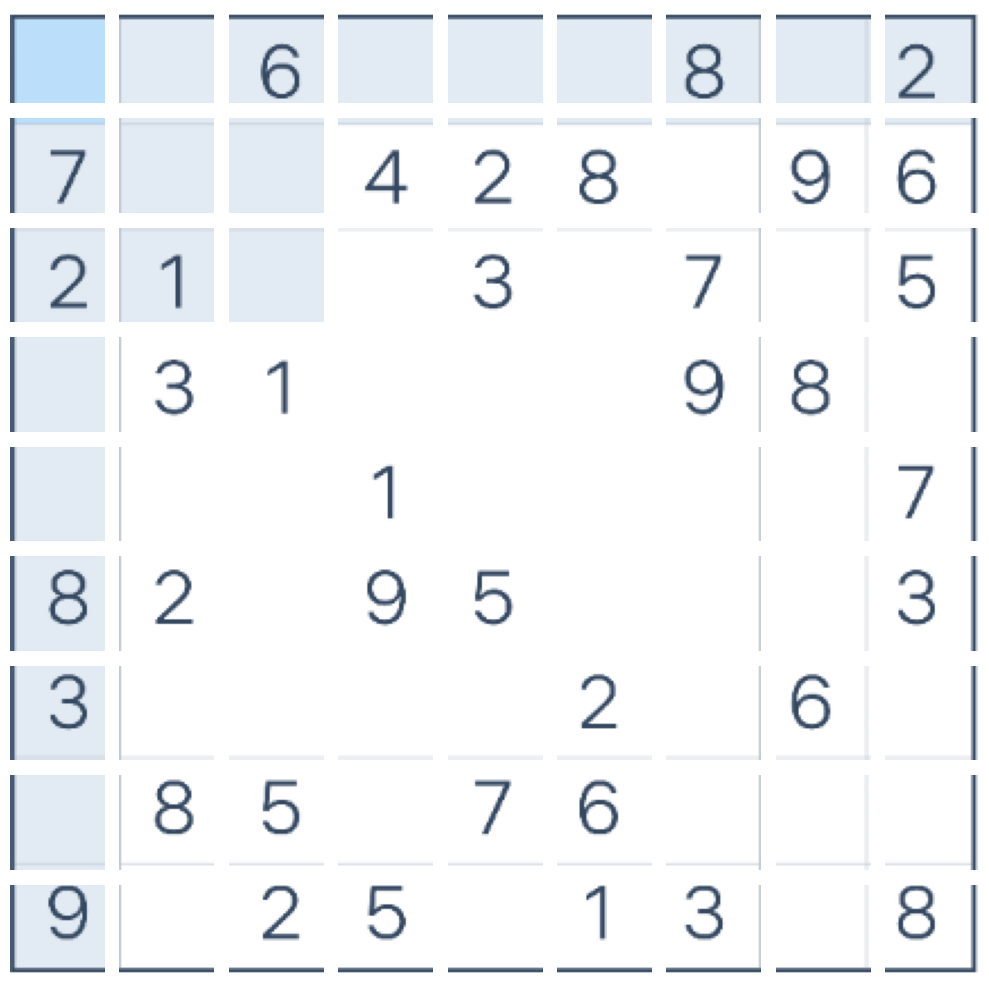

In [5]:
#visualizar para comprobar

plt.figure(figsize=(10, 10))

for fila in range(9):
    for col in range(9):
        plt.subplot(9, 9, fila * 9 + col + 1)
        plt.imshow(cv2.cvtColor(cells[fila][col], cv2.COLOR_BGR2RGB))
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
#preprocesamiento de celda para dejarla en blanco/negro

def preprocesar_celda(cell):
    gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (3, 3), 0)

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    return thresh

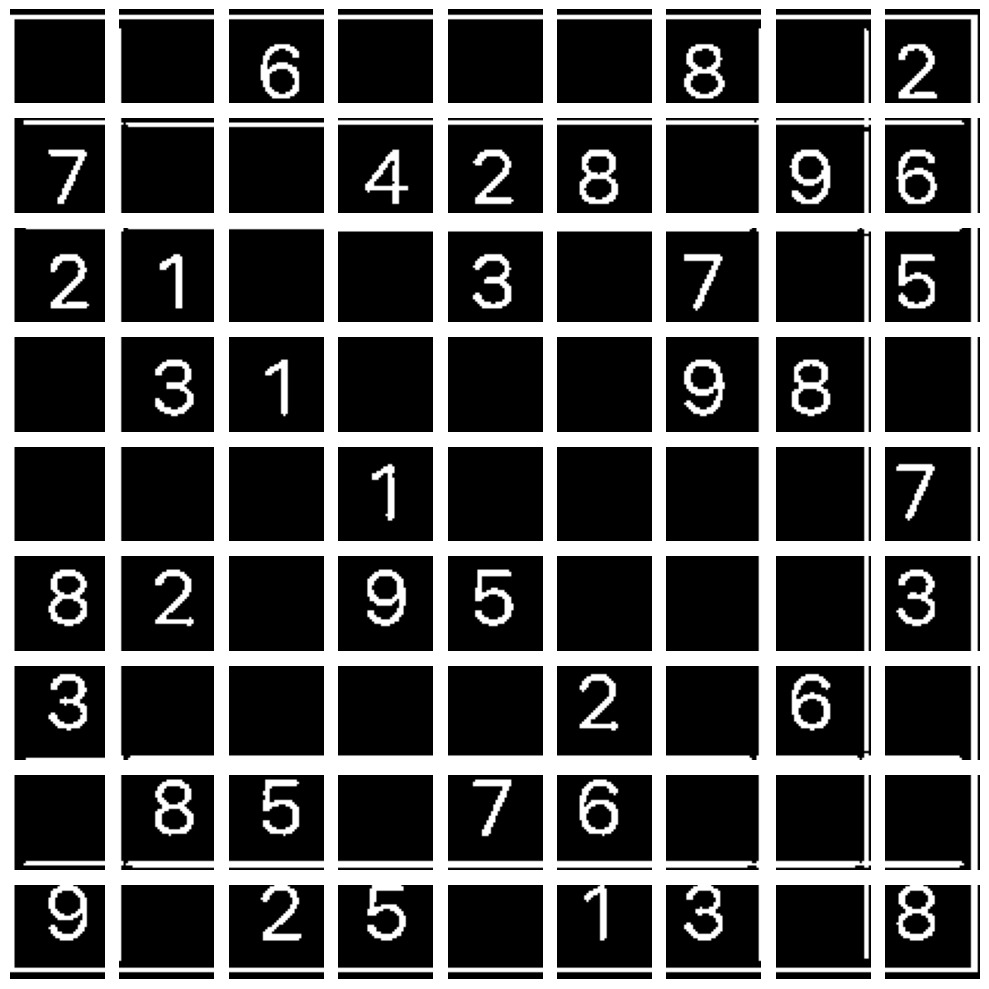

In [7]:
#visualizacion

plt.figure(figsize=(10, 10))

for fila in range(9):
    for col in range(9):
        plt.subplot(9, 9, fila * 9 + col + 1)

        cell_proc = preprocesar_celda(cells[fila][col])

        plt.imshow(cell_proc, cmap="gray")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
#recorte centro

def recortar_centro(cell_proc):

    h, w = cell_proc.shape

    y1 = int(h * 0.10)
    y2 = int(h * 0.90)

    x1 = int(w * 0.10)
    x2 = int(w * 0.90)

    return cell_proc[y1:y2, x1:x2]

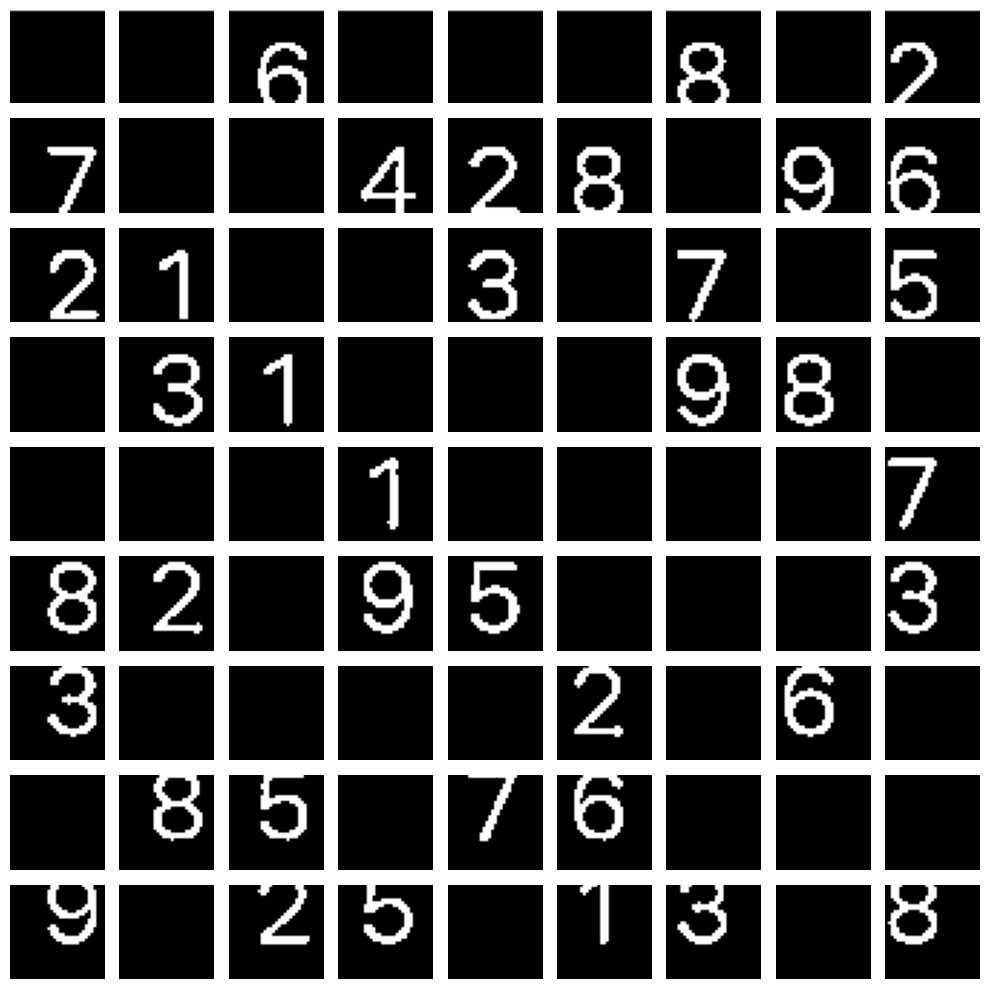

In [9]:
plt.figure(figsize=(10,10))

for fila in range(9):
    for col in range(9):

        plt.subplot(9,9,fila*9+col+1)

        proc = preprocesar_celda(cells[fila][col])

        centro = recortar_centro(proc)

        plt.imshow(centro, cmap="gray")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28, 1)
(60000,)


In [11]:
#crear modelo cnn sencillo

modelo_digitos = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_digitos.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_digitos.summary()

c:\Users\Miboo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#entrenamiento modelo

history = modelo_digitos.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9443 - loss: 0.1866 - val_accuracy: 0.9825 - val_loss: 0.0574
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9845 - loss: 0.0518 - val_accuracy: 0.9840 - val_loss: 0.0477
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9885 - loss: 0.0367 - val_accuracy: 0.9887 - val_loss: 0.0333
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9913 - loss: 0.0287 - val_accuracy: 0.9892 - val_loss: 0.0323
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9908 - val_loss: 0.0311


In [13]:
#preparar celda para prediccion
def preparar_para_cnn(cell):
    proc = preprocesar_celda(cell)
    proc = recortar_centro(proc)
    proc = cv2.resize(proc, (28, 28))
    proc = proc.astype("float32") / 255.0
    proc = proc.reshape(1, 28, 28, 1)
    return proc

In [14]:
#detectar celda vacia
def es_celda_vacia(cell, umbral=20):
    proc = preprocesar_celda(cell)
    proc = recortar_centro(proc)

    pixeles_blancos = cv2.countNonZero(proc)

    return pixeles_blancos < umbral

In [15]:
#predecir celda
def predecir_celda(cell, modelo):
    if es_celda_vacia(cell):
        return 0

    img = preparar_para_cnn(cell)

    pred = modelo.predict(img, verbose=0)
    numero = np.argmax(pred)

    return int(numero)

In [16]:
#generar matriz 9x9
def generar_matriz_sudoku(cells, modelo):
    matriz = []

    for fila in range(9):
        row = []

        for col in range(9):
            numero = predecir_celda(cells[fila][col], modelo)
            row.append(numero)

        matriz.append(row)

    return matriz

In [17]:
#ejecutar
matriz_sudoku = generar_matriz_sudoku(cells, modelo_digitos)

matriz_sudoku

[[5, 5, 6, 5, 5, 5, 2, 5, 7],
 [7, 0, 0, 2, 7, 2, 0, 9, 2],
 [7, 7, 0, 0, 3, 0, 7, 0, 7],
 [0, 3, 7, 0, 0, 0, 9, 2, 0],
 [0, 0, 0, 7, 0, 0, 0, 0, 7],
 [2, 2, 0, 4, 5, 0, 0, 0, 3],
 [5, 0, 0, 0, 0, 2, 0, 3, 0],
 [0, 4, 2, 0, 1, 9, 0, 0, 0],
 [5, 0, 4, 2, 0, 1, 9, 0, 1]]

In [18]:
#mejorar visualizacion
for fila in matriz_sudoku:
    print(fila)

[5, 5, 6, 5, 5, 5, 2, 5, 7]
[7, 0, 0, 2, 7, 2, 0, 9, 2]
[7, 7, 0, 0, 3, 0, 7, 0, 7]
[0, 3, 7, 0, 0, 0, 9, 2, 0]
[0, 0, 0, 7, 0, 0, 0, 0, 7]
[2, 2, 0, 4, 5, 0, 0, 0, 3]
[5, 0, 0, 0, 0, 2, 0, 3, 0]
[0, 4, 2, 0, 1, 9, 0, 0, 0]
[5, 0, 4, 2, 0, 1, 9, 0, 1]


## Primer intento: entrenamiento con MNIST

El modelo no generaliza correctamente sobre los dígitos del Sudoku debido a las diferencias de tipografía y preprocesado.

--------------------------------------------------
NUEVA SECCIÓN
--------------------------------------------------

## Segundo intento: generación automática de dataset sintético

In [19]:
#generar datos sinteticos

import cv2
import numpy as np
import random

IMG_SIZE = 28

def generar_imagen_digito(digit):
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    if digit == 0:
        # celda vacía
        ruido = np.random.normal(0, 4, (IMG_SIZE, IMG_SIZE))
        img = np.clip(img + ruido, 0, 255).astype(np.uint8)
        return img

    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = random.uniform(0.8, 1.1)
    thickness = random.choice([1, 2])

    text = str(digit)
    (tw, th), _ = cv2.getTextSize(text, font, scale, thickness)

    x = (IMG_SIZE - tw) // 2 + random.randint(-2, 2)
    y = (IMG_SIZE + th) // 2 + random.randint(-2, 2)

    cv2.putText(img, text, (x, y), font, scale, 255, thickness, cv2.LINE_AA)

    return img

In [20]:
#crear dataset

X = []
y = []

n_por_clase = 3000

for clase in range(10):
    for _ in range(n_por_clase):
        img = generar_imagen_digito(clase)
        X.append(img)
        y.append(clase)

X = np.array(X).astype("float32") / 255.0
y = np.array(y)

X = X.reshape(-1, 28, 28, 1)

print(X.shape)
print(y.shape)

(30000, 28, 28, 1)
(30000,)


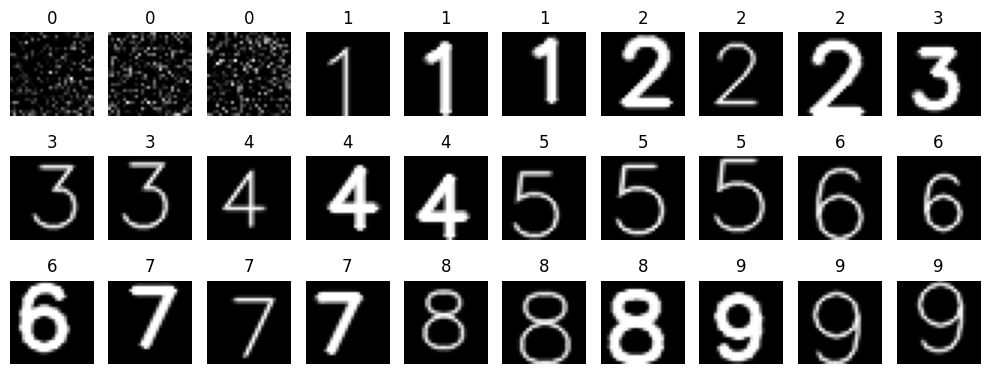

In [21]:
#visualizar ejemplos
plt.figure(figsize=(10, 4))

for i in range(30):
    plt.subplot(3, 10, i + 1)
    plt.imshow(X[i * 1000].reshape(28,28), cmap="gray")
    plt.title(y[i * 1000])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
#entrenar cnn nueva

modelo_digitos = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_digitos.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_digitos.fit(
    X, y,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9729 - loss: 0.1129 - val_accuracy: 0.0000e+00 - val_loss: 53.1172
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 2.8806e-04 - val_accuracy: 0.0000e+00 - val_loss: 60.0705
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 1.0985e-04 - val_accuracy: 0.0000e+00 - val_loss: 64.5301
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 1.0000 - loss: 5.5634e-05 - val_accuracy: 0.0000e+00 - val_loss: 68.3029
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 1.0000 - loss: 3.3848e-05 - val_accuracy: 0.0000e+00 - val_loss: 71.2549


In [23]:
matriz_sudoku = generar_matriz_sudoku(cells, modelo_digitos)

for fila in matriz_sudoku:
    print(fila)

[0, 0, 6, 0, 0, 0, 6, 0, 6]
[5, 0, 0, 4, 5, 6, 0, 6, 6]
[3, 3, 0, 0, 5, 0, 7, 0, 6]
[0, 3, 1, 0, 0, 0, 2, 6, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 6]
[3, 2, 0, 6, 5, 0, 0, 0, 2]
[3, 0, 0, 0, 0, 4, 0, 6, 0]
[0, 7, 2, 0, 7, 2, 0, 0, 0]
[3, 0, 4, 2, 0, 1, 4, 0, 6]


## Tercer intento: entrenar con celdas reales del sudoku

In [24]:
#etiquetas reales sudoku actual

puzzle_str = (
    "006000802"
    "700428096"
    "210030705"
    "031000980"
    "000100007"
    "820950003"
    "300002060"
    "085076000"
    "902501308"
)

assert len(puzzle_str) == 81

In [25]:
#preparar imagen base

def preparar_img_base(cell):
    proc = preprocesar_celda(cell)
    proc = recortar_centro(proc)
    proc = cv2.resize(proc, (28, 28))
    proc = proc.astype("float32") / 255.0
    return proc

In [26]:
#crear dataset desde mis 81 celdas
bases_por_clase = {i: [] for i in range(10)}

for fila in range(9):
    for col in range(9):
        idx = fila * 9 + col
        etiqueta = int(puzzle_str[idx])

        img = preparar_img_base(cells[fila][col])
        bases_por_clase[etiqueta].append(img)

for clase in range(10):
    print(clase, len(bases_por_clase[clase]))

0 43
1 4
2 6
3 5
4 1
5 4
6 4
7 4
8 6
9 4


In [27]:
#data augmentation

import random

def augmentar(img):
    h, w = img.shape

    angle = random.uniform(-4, 4)
    tx = random.uniform(-2, 2)
    ty = random.uniform(-2, 2)

    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    M[:, 2] += [tx, ty]

    aug = cv2.warpAffine(
        img,
        M,
        (w, h),
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return np.clip(aug, 0, 1)

In [28]:
#generar dataset equilibrado

X = []
y = []

n_por_clase = 1000

for clase in range(10):
    ejemplos = bases_por_clase[clase]

    for _ in range(n_por_clase):
        img_base = random.choice(ejemplos)
        img_aug = augmentar(img_base)

        X.append(img_aug)
        y.append(clase)

X = np.array(X).reshape(-1, 28, 28, 1)
y = np.array(y)

print(X.shape)
print(y.shape)

(10000, 28, 28, 1)
(10000,)


In [29]:
#entrenar cnn

modelo_digitos = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo_digitos.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = modelo_digitos.fit(
    X,
    y,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8413 - loss: 0.5215 - val_accuracy: 0.0000e+00 - val_loss: 30.1966
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9920 - loss: 0.0285 - val_accuracy: 0.0000e+00 - val_loss: 36.3031
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9998 - loss: 0.0055 - val_accuracy: 0.0000e+00 - val_loss: 39.7355
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.0000e+00 - val_loss: 42.5516
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 6.0457e-04 - val_accuracy: 0.0000e+00 - val_loss: 44.9815


In [30]:
#redefenir prediccion celda

def predecir_celda(cell, modelo):
    img = preparar_img_base(cell)
    img = img.reshape(1, 28, 28, 1)

    pred = modelo.predict(img, verbose=0)
    numero = int(np.argmax(pred))

    return numero

In [31]:
#generar matriz

matriz_sudoku = generar_matriz_sudoku(cells, modelo_digitos)

for fila in matriz_sudoku:
    print(fila)

[0, 0, 6, 0, 0, 0, 6, 0, 2]
[7, 0, 0, 4, 2, 3, 0, 6, 6]
[2, 1, 0, 0, 3, 0, 7, 0, 5]
[0, 3, 1, 0, 0, 0, 6, 6, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 7]
[3, 2, 0, 5, 5, 0, 0, 0, 3]
[3, 0, 0, 0, 0, 2, 0, 6, 0]
[0, 5, 5, 0, 7, 6, 0, 0, 0]
[3, 0, 2, 5, 0, 1, 3, 0, 6]


In [32]:
# Guardar modelo CNN
modelo_digitos.save("modelo_digitos_sudoku.keras")

print("Modelo guardado correctamente")

Modelo guardado correctamente
